Done


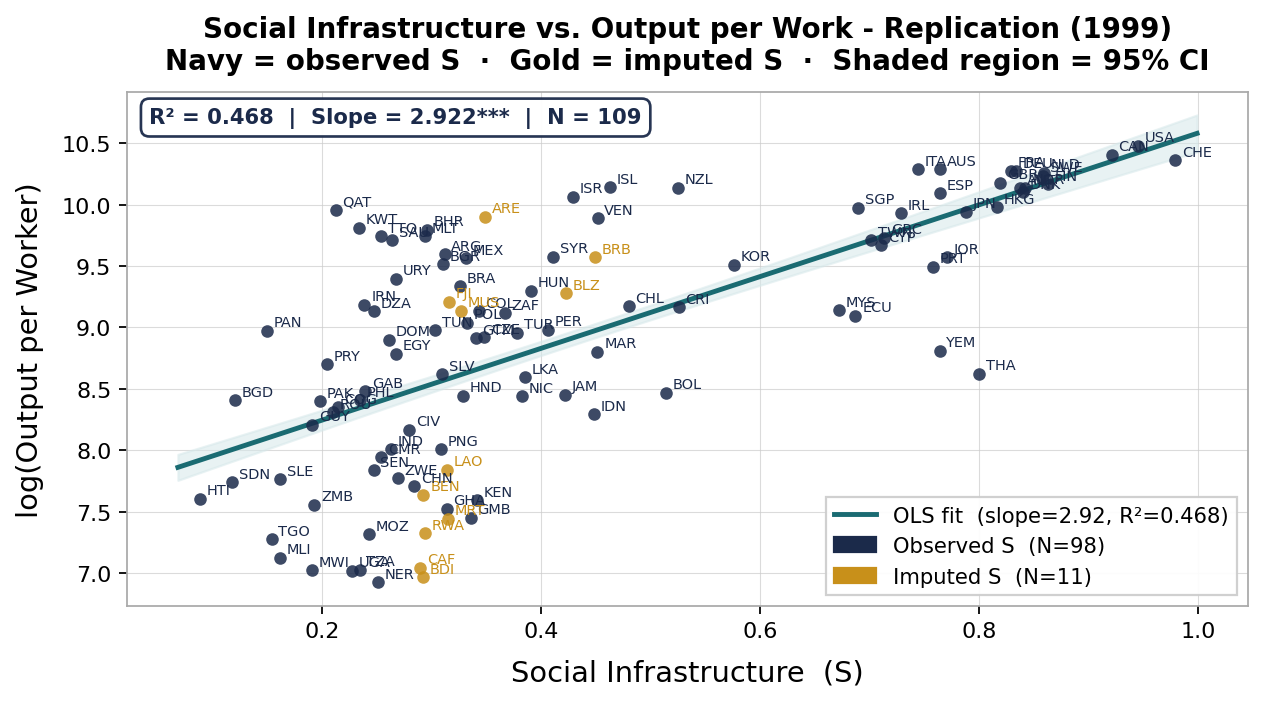

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats

# --- Settings: 1280 x 720 px (unchanged from original) ---
WIDTH_PX, HEIGHT_PX = 1280, 720
DPI = 160
WIDTH_IN, HEIGHT_IN = WIDTH_PX / DPI, HEIGHT_PX / DPI   # 8.0 x 4.5 inches

# --- Read data ---
df = pd.read_csv(r'C:\Users\Adams\OneDrive\DE & E Research\outputs\sample_B_replication.csv')

df['log_yl']  = np.log(df['yl_adj'])
df['S']       = df['social_infra']
df['imputed'] = df['si_was_imputed'].astype(bool)

obs = df[~df['imputed']]
imp = df[ df['imputed']]

N     = len(df)
N_obs = len(obs)
N_imp = len(imp)

# --- OLS regression ---
slope, intercept, r_value, p_value, se = stats.linregress(df['S'], df['log_yl'])
r2 = r_value ** 2

stars = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else ''))

# --- 95% confidence band ---
x_fit  = np.linspace(df['S'].min() - 0.02, df['S'].max() + 0.02, 300)
y_fit  = intercept + slope * x_fit
n      = len(df)
x_mean = df['S'].mean()
s_xx   = np.sum((df['S'] - x_mean) ** 2)
se_fit = se * np.sqrt(1/n + (x_fit - x_mean) ** 2 / s_xx)
t_crit = stats.t.ppf(0.975, df=n - 2)
y_upper = y_fit + t_crit * se_fit
y_lower = y_fit - t_crit * se_fit

# ── Colours matching Figure 2 ──────────────────────────────────────────────
NAVY       = '#1B2A4A'
GOLD       = '#C8901A'
TEAL       = '#1A6B72'
TEAL_LIGHT = '#D6E8EA'

# ── Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(WIDTH_IN, HEIGHT_IN), dpi=DPI)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Grid — solid light grey, matching Figure 2
ax.grid(True, color='#CCCCCC', linewidth=0.5, linestyle='-', alpha=0.7, zorder=0)
ax.set_axisbelow(True)

# 95% CI shaded band
ax.fill_between(x_fit, y_lower, y_upper, color=TEAL_LIGHT, alpha=0.55, zorder=1)

# OLS fit line
ax.plot(x_fit, y_fit, color=TEAL, linewidth=2.2, zorder=3)

# Scatter dots — size 32, matching Figure 2
ax.scatter(obs['S'], obs['log_yl'],
           color=NAVY, s=32, alpha=0.85, linewidths=0, zorder=4)
ax.scatter(imp['S'], imp['log_yl'],
           color=GOLD, s=32, alpha=0.85, linewidths=0, zorder=5)

# ISO-3 country labels
for _, row in df.iterrows():
    color = GOLD if row['imputed'] else NAVY
    ax.annotate(row['iso3'],
                xy=(row['S'], row['log_yl']),
                xytext=(3, 2), textcoords='offset points',
                fontsize=6.5, color=color, zorder=6)

# Stat box — single line, navy border, bold (matching Figure 2)
ax.text(
    0.02, 0.97,
    f"R² = {r2:.3f}  |  Slope = {slope:.3f}{stars}  |  N = {N}",
    transform=ax.transAxes,
    fontsize=9.5, fontweight='bold', color=NAVY,
    verticalalignment='top', horizontalalignment='left',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor=NAVY, linewidth=1.2, alpha=0.95),
    zorder=7,
)

# Axis labels
ax.set_xlabel('Social Infrastructure  (S)', fontsize=13, labelpad=8)
ax.set_ylabel('log(Output per Worker)',      fontsize=13, labelpad=8)

# Two-line bold title (matching Figure 2 format)
ax.set_title(
    'Social Infrastructure vs. Output per Work - Replication (1999)\n'
    'Navy = observed S  ·  Gold = imputed S  ·  Shaded region = 95% CI',
    fontsize=12.5, fontweight='bold', pad=10,
)

ax.tick_params(labelsize=10)

# Legend — lower right, three entries matching Figure 2
ax.legend(
    handles=[
        Line2D([0], [0], color=TEAL, linewidth=2.2,
               label=f'OLS fit  (slope={slope:.2f}, R²={r2:.3f})'),
        mpatches.Patch(color=NAVY, label=f'Observed S  (N={N_obs})'),
        mpatches.Patch(color=GOLD, label=f'Imputed S  (N={N_imp})'),
    ],
    loc='lower right', fontsize=9.5,
    frameon=True, framealpha=0.92, edgecolor='#CCCCCC', fancybox=False,
)

# Spine styling
for sp in ax.spines.values():
    sp.set_edgecolor('#AAAAAA')
    sp.set_linewidth(0.8)

# Save — bbox_inches='tight' prevents title clipping at 1280x720
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig(
    r'C:\Users\Adams\OneDrive\DE & E Research\outputs\fig_yl_vs_S_extension_sampleB_replication.png',
    dpi=DPI,
    bbox_inches='tight',
    facecolor='white',
    pad_inches=0.05,
)
print("Done")

Done


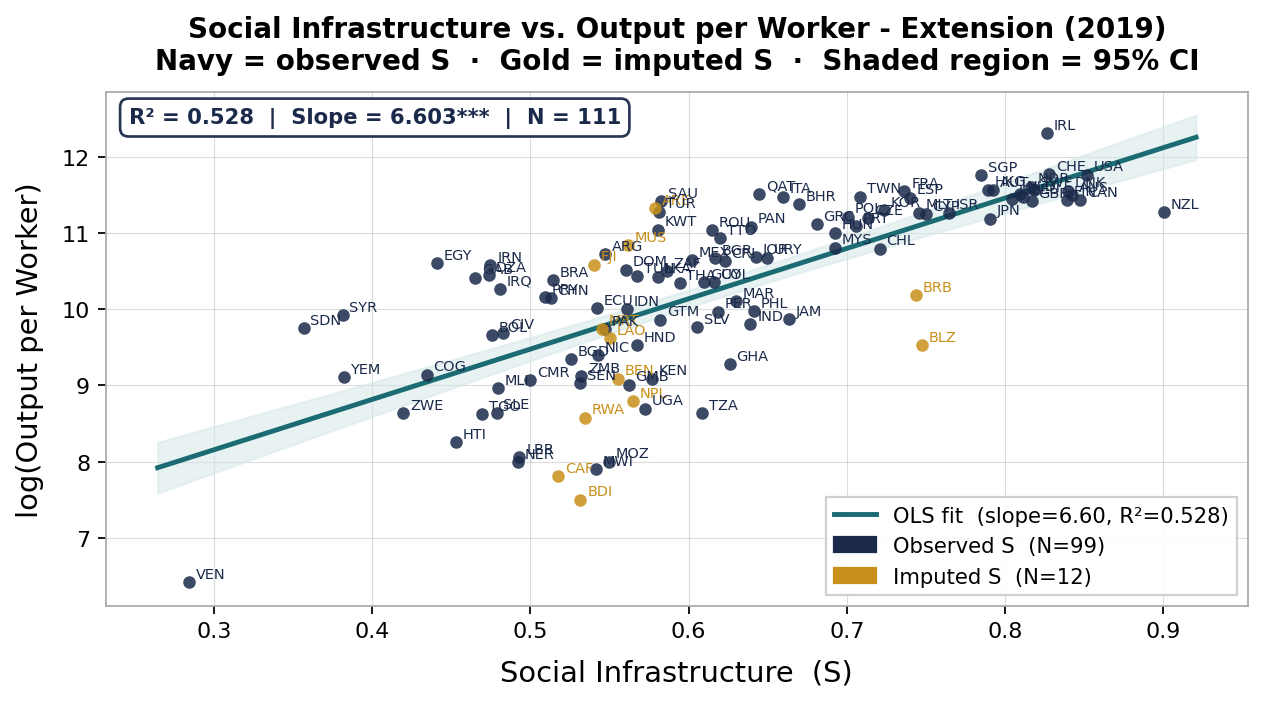

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats

# --- Settings: 1280 x 720 px (unchanged from original) ---
WIDTH_PX, HEIGHT_PX = 1280, 720
DPI = 160
WIDTH_IN, HEIGHT_IN = WIDTH_PX / DPI, HEIGHT_PX / DPI   # 8.0 x 4.5 inches

# --- Read data ---
df = pd.read_csv(r'C:\Users\Adams\OneDrive\DE & E Research\outputs\sample_B_replication_extended.csv')

df['log_yl']  = np.log(df['yl_adj'])
df['S']       = df['social_infra']
df['imputed'] = df['si_was_imputed'].astype(bool)

obs = df[~df['imputed']]
imp = df[ df['imputed']]

N     = len(df)
N_obs = len(obs)
N_imp = len(imp)

# --- OLS regression ---
slope, intercept, r_value, p_value, se = stats.linregress(df['S'], df['log_yl'])
r2 = r_value ** 2

stars = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else ''))

# --- 95% confidence band ---
x_fit  = np.linspace(df['S'].min() - 0.02, df['S'].max() + 0.02, 300)
y_fit  = intercept + slope * x_fit
n      = len(df)
x_mean = df['S'].mean()
s_xx   = np.sum((df['S'] - x_mean) ** 2)
se_fit = se * np.sqrt(1/n + (x_fit - x_mean) ** 2 / s_xx)
t_crit = stats.t.ppf(0.975, df=n - 2)
y_upper = y_fit + t_crit * se_fit
y_lower = y_fit - t_crit * se_fit

# ── Colours matching Figure 2 ──────────────────────────────────────────────
NAVY       = '#1B2A4A'
GOLD       = '#C8901A'
TEAL       = '#1A6B72'
TEAL_LIGHT = '#D6E8EA'

# ── Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(WIDTH_IN, HEIGHT_IN), dpi=DPI)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Grid — solid light grey, matching Figure 2
ax.grid(True, color='#CCCCCC', linewidth=0.5, linestyle='-', alpha=0.7, zorder=0)
ax.set_axisbelow(True)

# 95% CI shaded band
ax.fill_between(x_fit, y_lower, y_upper, color=TEAL_LIGHT, alpha=0.55, zorder=1)

# OLS fit line
ax.plot(x_fit, y_fit, color=TEAL, linewidth=2.2, zorder=3)

# Scatter dots — size 32, matching Figure 2
ax.scatter(obs['S'], obs['log_yl'],
           color=NAVY, s=32, alpha=0.85, linewidths=0, zorder=4)
ax.scatter(imp['S'], imp['log_yl'],
           color=GOLD, s=32, alpha=0.85, linewidths=0, zorder=5)

# ISO-3 country labels
for _, row in df.iterrows():
    color = GOLD if row['imputed'] else NAVY
    ax.annotate(row['iso3'],
                xy=(row['S'], row['log_yl']),
                xytext=(3, 2), textcoords='offset points',
                fontsize=6.5, color=color, zorder=6)

# Stat box — single line, navy border, bold (matching Figure 2)
ax.text(
    0.02, 0.97,
    f"R² = {r2:.3f}  |  Slope = {slope:.3f}{stars}  |  N = {N}",
    transform=ax.transAxes,
    fontsize=9.5, fontweight='bold', color=NAVY,
    verticalalignment='top', horizontalalignment='left',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor=NAVY, linewidth=1.2, alpha=0.95),
    zorder=7,
)

# Axis labels
ax.set_xlabel('Social Infrastructure  (S)', fontsize=13, labelpad=8)
ax.set_ylabel('log(Output per Worker)',      fontsize=13, labelpad=8)

# Two-line bold title (matching Figure 2 format)
ax.set_title(
    'Social Infrastructure vs. Output per Worker - Extension (2019)\n'
    'Navy = observed S  ·  Gold = imputed S  ·  Shaded region = 95% CI',
    fontsize=12.5, fontweight='bold', pad=10,
)

ax.tick_params(labelsize=10)

# Legend — lower right, three entries matching Figure 2
ax.legend(
    handles=[
        Line2D([0], [0], color=TEAL, linewidth=2.2,
               label=f'OLS fit  (slope={slope:.2f}, R²={r2:.3f})'),
        mpatches.Patch(color=NAVY, label=f'Observed S  (N={N_obs})'),
        mpatches.Patch(color=GOLD, label=f'Imputed S  (N={N_imp})'),
    ],
    loc='lower right', fontsize=9.5,
    frameon=True, framealpha=0.92, edgecolor='#CCCCCC', fancybox=False,
)

# Spine styling
for sp in ax.spines.values():
    sp.set_edgecolor('#AAAAAA')
    sp.set_linewidth(0.8)

# Save — bbox_inches='tight' prevents title clipping at 1280x720
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig(
    r'C:\Users\Adams\OneDrive\DE & E Research\outputs\fig_yl_vs_S_extension_sampleB_extension.png',
    dpi=DPI,
    bbox_inches='tight',
    facecolor='white',
    pad_inches=0.05,
)
print("Done")